#Understanding Musical Context Using a Hybrid BERT and Graph Neural Network Framework

# Table of Contents

1. Project Overview
2. Environment Setup
3. Project Configuration
4. Dataset Loading
   - 4.5 Task 1: BERT Multi-Label Tagging (MusicCaps)
5. Exploratory Data Analysis
6. Data Preprocessing
   - 6.12 Baseline Models (Majority Class, PCA + MLP)
7. BERT Baseline Model (FMA genre text)
8. GNN Baseline Model
9. BERT + GNN Fusion Models
   - Concatenation Fusion
   - Cross-Attention Fusion
   - Tag-Aware Gated Fusion
   - Ablation Summary
10. Final Evaluation (Comparison Table, AUC-PR, Plots, Confusion Matrix, t-SNE, Case Studies)
11. Conclusion

## 2.1 Import Libraries

In [ ]:
# 2.1 Import Required Libraries

import os
import random
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim


from transformers import BertTokenizer, BertModel


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


print("Libraries imported successfully")

Libraries imported successfully


## 2.2 Check Hardware Availability


In [ ]:
# 2.2 Hardware Configuration

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


## 2.3 Set Reproducibility


In [ ]:
# 2.3 Reproducibility Setup

SEED = 42


random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


print("Random seed set to:", SEED)

Random seed set to: 42


Mounting drive

In [ ]:
# 2.4 Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##3. Project Configuration

In [ ]:
# 3.1 Define Project Paths

import os


PROJECT_PATH = "/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project"


DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

RAW_DATA_PATH = os.path.join(
    DATA_PATH,
    "raw"
)

PROCESSED_DATA_PATH = os.path.join(
    DATA_PATH,
    "processed"
)


MUSICCAPS_PATH = os.path.join(
    RAW_DATA_PATH,
    "musiccaps",
    "musiccaps-public.csv"
)


FMA_PATH = os.path.join(
    RAW_DATA_PATH,
    "fma"
)


MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)


RESULT_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)


print("Project paths configured successfully")

Project paths configured successfully


In [ ]:
# 3.2 Create Directories

directories = [
    DATA_PATH,
    RAW_DATA_PATH,
    PROCESSED_DATA_PATH,
    MODEL_PATH,
    RESULT_PATH
]


for directory in directories:
    os.makedirs(
        directory,
        exist_ok=True
    )


print("Directory structure ready")

Directory structure ready


In [ ]:
# 3.3 Training Configuration

SEED = 42

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

EPOCHS = 20


NUM_CLASSES = 8


BERT_MODEL_NAME = "bert-base-uncased"


print("Configuration loaded successfully")

Configuration loaded successfully


Verifying file paths


In [ ]:
# 3.4 Check FMA Folder Structure

import os

fma_folder = os.path.join(
    PROJECT_PATH,
    "data",
    "raw",
    "fma"
)


for root, dirs, files in os.walk(fma_folder):

    level = root.replace(fma_folder, "").count(os.sep)

    if level <= 2:
        print(root)

        for f in files[:5]:
            print("   ", f)

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma
    fma_metadata.zip
    fma_small.zip
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata
    README.txt
    checksums
    not_found.pickle
    raw_genres.csv
    raw_albums.csv


In [ ]:
# 3.5 Find FMA Metadata Files

import os

metadata_root = os.path.join(
    FMA_PATH,
    "fma_metadata"
)


for root, dirs, files in os.walk(metadata_root):

    for file in files:

        if file in [
            "tracks.csv",
            "genres.csv",
            "features.csv"
        ]:
            print(
                os.path.join(root, file)
            )

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/tracks.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/genres.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/features.csv


In [ ]:
# 3.6 Verify MusicCaps Files

print(os.listdir(
    os.path.join(
        PROJECT_PATH,
        "data",
        "raw",
        "musiccaps"
    )
))

['musiccaps-public.csv']


## 4. Dataset Loading


In [ ]:
# 4.1 Dataset Paths

FMA_METADATA_PATH = os.path.join(
    FMA_PATH,
    "fma_metadata",
    "fma_metadata"
)


TRACKS_PATH = os.path.join(
    FMA_METADATA_PATH,
    "tracks.csv"
)


GENRES_PATH = os.path.join(
    FMA_METADATA_PATH,
    "genres.csv"
)


FEATURES_PATH = os.path.join(
    FMA_METADATA_PATH,
    "features.csv"
)


print(TRACKS_PATH)
print(GENRES_PATH)
print(FEATURES_PATH)

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/tracks.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/genres.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/features.csv


In [ ]:
# 4.2 Load MusicCaps Dataset

musiccaps = pd.read_csv(
    MUSICCAPS_PATH
)


print(
    "MusicCaps shape:",
    musiccaps.shape
)


musiccaps.head()

MusicCaps shape: (5521, 9)


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [ ]:
# 4.3 Load FMA Metadata

tracks = pd.read_csv(
    TRACKS_PATH,
    header=[0,1],
    index_col=0
)


genres = pd.read_csv(
    GENRES_PATH
)


features = pd.read_csv(
    FEATURES_PATH,
    header=[0,1],
    index_col=0
)


print(
    "Tracks:",
    tracks.shape
)

print(
    "Genres:",
    genres.shape
)

print(
    "Features:",
    features.shape
)

/tmp/ipykernel_2409/4265829559.py:18: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(


Tracks: (106574, 52)
Genres: (163, 5)
Features: (106576, 518)


In [ ]:
# 4.4 Dataset Preview

print("MusicCaps")
display(
    musiccaps.head()
)


print("\nGenres")
display(
    genres.head()
)


print("\nTracks")
display(
    tracks.head()
)

MusicCaps


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False



Genres


,genre_id,#tracks,parent,title,top_level
0,1,8693,38,Avant-Garde,38
1,2,5271,0,International,2
2,3,1752,0,Blues,3
3,4,4126,0,Jazz,4
4,5,4106,0,Classical,5



Tracks


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

## 5. Exploratory Data Analysis


In [ ]:
# 5.1 Import EDA Libraries

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

print("EDA libraries imported successfully")

EDA libraries imported successfully


In [ ]:
# 5.2 Dataset Information

print("MusicCaps Dataset")
print("-----------------")
print(musiccaps.info())


print("\nFMA Tracks Dataset")
print("-----------------")
print(tracks.info())


print("\nFMA Genres Dataset")
print("-----------------")
print(genres.info())


print("\nFMA Features Dataset")
print("-----------------")
print(features.info())

MusicCaps Dataset
-----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5521 entries, 0 to 5520
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   ytid                      5521 non-null   object
 1   start_s                   5521 non-null   int64 
 2   end_s                     5521 non-null   int64 
 3   audioset_positive_labels  5521 non-null   object
 4   aspect_list               5521 non-null   object
 5   caption                   5521 non-null   object
 6   author_id                 5521 non-null   int64 
 7   is_balanced_subset        5521 non-null   bool  
 8   is_audioset_eval          5521 non-null   bool  
dtypes: bool(2), int64(3), object(4)
memory usage: 312.8+ KB
None

FMA Tracks Dataset
-----------------
<class 'pandas.core.frame.DataFrame'>
Index: 106574 entries, 2 to 155320
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dty

In [ ]:
# 5.3 Missing Values

print("MusicCaps Missing Values")
display(
    musiccaps.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)


print("Tracks Missing Values")
display(
    tracks.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

MusicCaps Missing Values


,0
ytid,0
start_s,0
end_s,0
audioset_positive_labels,0
aspect_list,0
caption,0
author_id,0
is_balanced_subset,0
is_audioset_eval,0


Tracks Missing Values


track   lyricist             106263
        publisher            105311
        information          104225
        composer             102904
artist  active_year_end      101199
        wikipedia_page       100993
track   date_recorded        100415
artist  related_projects      93422
        associated_labels     92303
track   language_code         91550
dtype: int64

In [ ]:
# 5.4 Caption Length Analysis

musiccaps["caption_length"] = (
    musiccaps["caption"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


print(
    musiccaps["caption_length"]
    .describe()
)

count    5521.000000
mean       48.968303
std        17.329780
min         3.000000
25%        37.000000
50%        46.000000
75%        60.000000
max       136.000000
Name: caption_length, dtype: float64


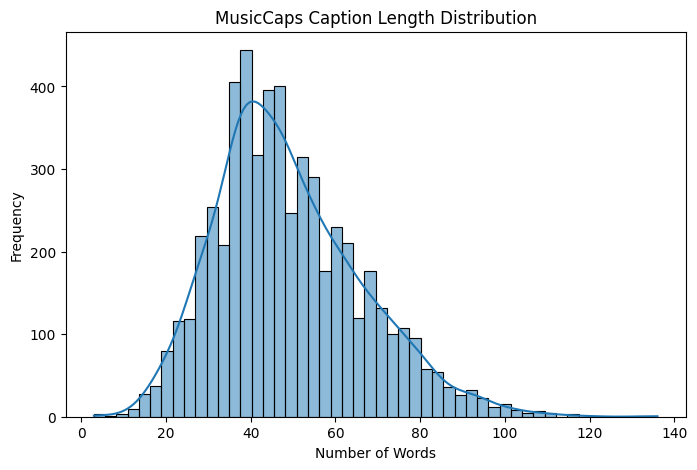

In [ ]:
# 5.5 Caption Length Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    musiccaps["caption_length"],
    bins=50,
    kde=True
)

plt.title(
    "MusicCaps Caption Length Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Frequency"
)

plt.show()

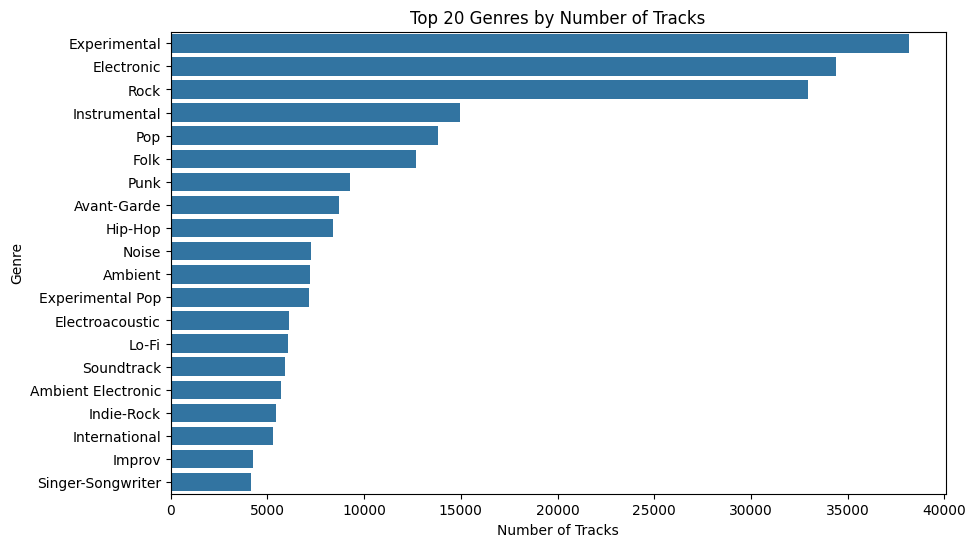

In [ ]:
# 5.6 Genre Distribution

plt.figure(figsize=(10,6))


sns.barplot(
    data=genres.sort_values(
        "#tracks",
        ascending=False
    ).head(20),
    x="#tracks",
    y="title"
)


plt.title(
    "Top 20 Genres by Number of Tracks"
)


plt.xlabel(
    "Number of Tracks"
)

plt.ylabel(
    "Genre"
)


plt.show()

In [ ]:
# 5.7 Feature Statistics

features.describe().T.head(20)

count      mean        std       min       25%  \
feature     statistics                                                       
chroma_cens kurtosis     106575.0  0.440005  32.285372 -1.955806 -0.636594   
            kurtosis.1   106575.0  0.199773  11.120852 -1.936607 -0.665679   
            kurtosis.2   106575.0  0.334708   9.980649 -1.967450 -0.629107   
            kurtosis.3   106575.0  0.270298  19.074470 -3.000000 -0.644744   
            kurtosis.4   106575.0  0.294850  15.025539 -1.921206 -0.656778   
            kurtosis.5   106575.0  0.315688  12.176137 -1.923740 -0.622574   
            kurtosis.6   106575.0  0.273574  16.975923 -1.935382 -0.646797   
            kurtosis.7   106575.0  0.334999  15.486347 -3.000000 -0.635741   
            kurtosis.8   106575.0  0.202021   7.364323 -3.000000 -0.667792   
            kurtosis.9   106575.0  0.285723   8.175272 -3.000000 -0.660292   
            kurtosis.10  106575.0  0.430648  19.343051 -3.000000 -0.636308   
            kurtosis.11  106575.0  0.474122  22.967582 -3.000000 -0.641433   
            max          106575.0  0.622669   0.086202  0.021007  0.571389   
            max.1        106575.0  0.593434   0.083409  0.051882  0.527863   
            max.2        106575.0  0.610023   0.089285  0.054485  0.546874   
            max.3        106575.0  0.588966   0.087890  0.000000  0.517307   
            max.4        106575.0  0.608219   0.090670  0.038674  0.546217   
            max.5        106575.0  0.596043   0.092477  0.021914  0.524485   
            max.6        106575.0  0.590459   0.091592  0.020285  0.518642   
            max.7        106575.0  0.612545   0.092319  0.000000  0.553730   

                              50%       75%          max  
feature     statistics                                    
chroma_cens kurtosis    -0.176543  0.485025  8843.367188  
            kurtosis.1  -0.221117  0.410119  2864.075195  
            kurtosis.2  -0.152701  0.529845  1777.615967  
            kurtosis.3  -0.191018  0.446832  4257.045898  
            kurtosis.4  -0.198022  0.452694  3188.034424  
            kurtosis.5  -0.152085  0.513130  2809.779297  
            kurtosis.6  -0.187953  0.472191  4281.090820  
            kurtosis.7  -0.161462  0.525828  3869.482178  
            kurtosis.8  -0.214531  0.432492  1217.209473  
            kurtosis.9  -0.181827  0.495605  1772.918213  
            kurtosis.10 -0.160666  0.534784  3887.379639  
            kurtosis.11 -0.169869  0.525563  4995.784668  
            max          0.642001  0.684615     1.000000  
            max.1        0.611782  0.661019     2.000000  
            max.2        0.636942  0.680844     3.000000  
            max.3        0.607987  0.660162     4.000000  
            max.4        0.635373  0.679211     5.000000  
            max.5        0.620019  0.670589     6.000000  
            max.6        0.611707  0.663647     7.000000  
            max.7        0.640468  0.682266     8.000000

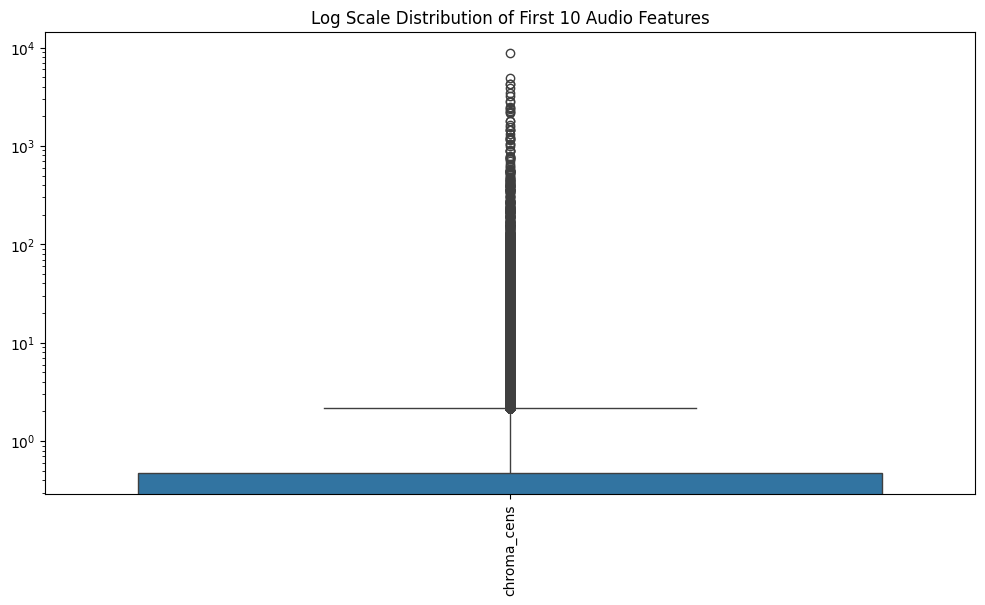

In [ ]:
# 5.8 Improved Feature Distribution

feature_sample = features.iloc[:, :10]


plt.figure(figsize=(12,6))


sns.boxplot(
    data=feature_sample
)


plt.xticks(
    rotation=90
)

plt.yscale("log")

plt.title(
    "Log Scale Distribution of First 10 Audio Features"
)


plt.show()

In [ ]:
# 5.9 EDA Summary

eda_summary = pd.DataFrame({
    "Dataset": [
        "MusicCaps",
        "FMA Tracks",
        "FMA Genres",
        "FMA Features"
    ],

    "Samples": [
        musiccaps.shape[0],
        tracks.shape[0],
        genres.shape[0],
        features.shape[0]
    ],

    "Features": [
        musiccaps.shape[1],
        tracks.shape[1],
        genres.shape[1],
        features.shape[1]
    ]
})


eda_summary

,Dataset,Samples,Features
0,MusicCaps,5521,10
1,FMA Tracks,106574,52
2,FMA Genres,163,5
3,FMA Features,106576,518


## 4.5 Task 1: BERT Multi-Label Tag Classification (MusicCaps)



In [ ]:
# 4.5.1 Load Tokenizer and Device

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Tokenizer and device ready:", device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer and device ready: cuda


In [ ]:
# 4.5.2 Parse and Normalize Aspect Labels

import ast
from collections import Counter


def parse_aspects(value):

    if isinstance(value, list):
        return value

    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []


musiccaps["parsed_aspects"] = musiccaps["aspect_list"].apply(parse_aspects)


aspect_synonyms = {
    "male voice": "male vocal",
    "male singer": "male vocal",
    "female voice": "female vocal",
    "female singer": "female vocal",
    "e-guitar": "electric guitar",
    "e-bass": "bass guitar",
    "bass": "bass guitar",
    "instrumental music": "instrumental",
    "moderate tempo": "medium tempo",
    "uptempo": "fast tempo"
}


def normalize_aspects(aspects):

    cleaned = []

    for tag in aspects:

        tag = tag.strip().lower()
        tag = aspect_synonyms.get(tag, tag)

        if tag not in cleaned:
            cleaned.append(tag)

    return cleaned


musiccaps["normalized_aspects"] = musiccaps["parsed_aspects"].apply(normalize_aspects)


tag_counts = Counter()

for aspects in musiccaps["normalized_aspects"]:
    tag_counts.update(aspects)


NUM_LABELS = 30

task1_labels = [tag for tag, count in tag_counts.most_common(NUM_LABELS)]

print("Top", NUM_LABELS, "aspect labels for Task 1:")
for i, tag in enumerate(task1_labels, start=1):
    print(f"{i:2d}. {tag} ({tag_counts[tag]})")

Top 30 aspect labels for Task 1:
 1. low quality (1217)
 2. instrumental (1148)
 3. medium tempo (819)
 4. bass guitar (696)
 5. fast tempo (627)
 6. noisy (626)
 7. male vocal (625)
 8. emotional (620)
 9. energetic (593)
10. passionate (592)
11. amateur recording (515)
12. slow tempo (473)
13. live performance (468)
14. electric guitar (444)
15. acoustic drums (393)
16. mono (357)
17. groovy (321)
18. female vocal (306)
19. acoustic guitar (290)
20. piano (239)
21. punchy kick (236)
22. punchy snare (235)
23. groovy bass (228)
24. happy (225)
25. poor audio quality (221)
26. shimmering hi hats (217)
27. rock (207)
28. percussion (206)
29. no voices (202)
30. pop (197)


In [ ]:
# 4.5.3 Build Multi-Label Targets

def make_label_vector(aspects):

    return [
        1 if label in aspects else 0
        for label in task1_labels
    ]


musiccaps["task1_labels"] = musiccaps["normalized_aspects"].apply(make_label_vector)

task1_df = musiccaps[
    musiccaps["task1_labels"].apply(sum) > 0
].copy()


print("Total MusicCaps rows:", len(musiccaps))
print("Usable Task 1 rows (at least one label):", len(task1_df))

Total MusicCaps rows: 5521
Usable Task 1 rows (at least one label): 4921


In [ ]:
# 4.5.4 Train/Validation/Test Split

from sklearn.model_selection import train_test_split


task1_train_df, task1_temp_df = train_test_split(
    task1_df,
    test_size=0.20,
    random_state=42
)

task1_val_df, task1_test_df = train_test_split(
    task1_temp_df,
    test_size=0.50,
    random_state=42
)


print("Train:", len(task1_train_df))
print("Validation:", len(task1_val_df))
print("Test:", len(task1_test_df))

Train: 3936
Validation: 492
Test: 493


In [ ]:
# 4.5.5 Dataset Class and DataLoaders

from torch.utils.data import Dataset, DataLoader


class MusicCapsDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=128):

        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        encoding = self.tokenizer(
            row["caption"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        labels = torch.tensor(row["task1_labels"], dtype=torch.float)

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }


task1_train_dataset = MusicCapsDataset(task1_train_df, tokenizer)
task1_val_dataset = MusicCapsDataset(task1_val_df, tokenizer)
task1_test_dataset = MusicCapsDataset(task1_test_df, tokenizer)

task1_train_loader = DataLoader(task1_train_dataset, batch_size=16, shuffle=True)
task1_val_loader = DataLoader(task1_val_dataset, batch_size=16, shuffle=False)
task1_test_loader = DataLoader(task1_test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(task1_train_loader))
print("Validation batches:", len(task1_val_loader))
print("Test batches:", len(task1_test_loader))

Train batches: 246
Validation batches: 31
Test batches: 31


In [ ]:
# 4.5.6 Load BERT Multi-Label Model

from transformers import BertForSequenceClassification
from torch.optim import AdamW


task1_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(task1_labels),
    problem_type="multi_label_classification"
).to(device)

task1_optimizer = AdamW(task1_model.parameters(), lr=2e-5)

print("Task 1 model ready, output labels:", task1_model.config.num_labels)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Task 1 model ready, output labels: 30


In [ ]:
# 4.5.7 Training and Evaluation Functions

def task1_train_epoch(model, loader, optimizer, device):

    model.train()
    total_loss = 0

    for batch in loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        outputs.loss.backward()
        optimizer.step()

        total_loss += outputs.loss.item()

    return total_loss / len(loader)


def task1_evaluate(model, loader, device, threshold=0.5):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = torch.sigmoid(outputs.logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(batch["labels"].numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    predictions = (all_probs >= threshold).astype(int)

    micro_f1 = f1_score(all_labels, predictions, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, predictions, average="macro", zero_division=0)

    return micro_f1, macro_f1, all_probs, all_labels


print("Task 1 train/eval functions ready")

Task 1 train/eval functions ready


In [ ]:
# 4.5.8 Train Task 1 Model

import copy

EPOCHS = 5
patience = 2

task1_history = {"train_loss": [], "val_micro_f1": [], "val_macro_f1": []}

best_val_macro_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):

    train_loss = task1_train_epoch(task1_model, task1_train_loader, task1_optimizer, device)

    val_micro_f1, val_macro_f1, _, _ = task1_evaluate(task1_model, task1_val_loader, device)

    task1_history["train_loss"].append(train_loss)
    task1_history["val_micro_f1"].append(val_micro_f1)
    task1_history["val_macro_f1"].append(val_macro_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | "
          f"Val Micro-F1: {val_micro_f1:.4f} | Val Macro-F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_state = copy.deepcopy(task1_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

task1_model.load_state_dict(best_state)
print(f"\nBest validation Macro-F1: {best_val_macro_f1:.4f}")

Epoch 1/5 | Loss: 0.3337 | Val Micro-F1: 0.2061 | Val Macro-F1: 0.0530
Epoch 2/5 | Loss: 0.2235 | Val Micro-F1: 0.4625 | Val Macro-F1: 0.2213
Epoch 3/5 | Loss: 0.1865 | Val Micro-F1: 0.5710 | Val Macro-F1: 0.3600
Epoch 4/5 | Loss: 0.1627 | Val Micro-F1: 0.6346 | Val Macro-F1: 0.4434
Epoch 5/5 | Loss: 0.1433 | Val Micro-F1: 0.6954 | Val Macro-F1: 0.5683

Best validation Macro-F1: 0.5683


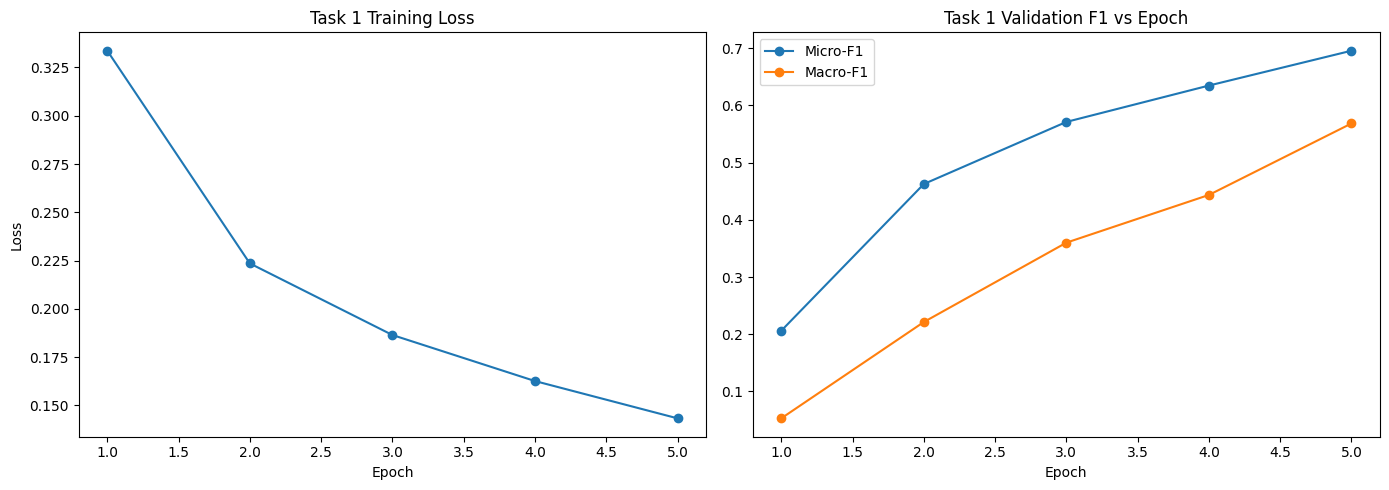

In [ ]:
# 4.5.9 Training Curves

epochs_range = range(1, len(task1_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(epochs_range, task1_history["train_loss"], marker="o")
axes[0].set_title("Task 1 Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epochs_range, task1_history["val_micro_f1"], marker="o", label="Micro-F1")
axes[1].plot(epochs_range, task1_history["val_macro_f1"], marker="o", label="Macro-F1")
axes[1].set_title("Task 1 Validation F1 vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 4.5.10 Test Set Evaluation

from sklearn.metrics import average_precision_score

test_micro_f1, test_macro_f1, test_probs, test_labels = task1_evaluate(
    task1_model, task1_test_loader, device
)

task1_auc_pr = average_precision_score(test_labels, test_probs, average="macro")

print("Task 1 Test Results")
print("Micro-F1:", test_micro_f1)
print("Macro-F1:", test_macro_f1)
print("Macro AUC-PR:", task1_auc_pr)

Task 1 Test Results
Micro-F1: 0.7001287001287001
Macro-F1: 0.5700671988867992
Macro AUC-PR: 0.707454604861113


In [ ]:
# 4.5.11 Example Predictions

sample_indices = np.random.RandomState(42).choice(len(task1_test_df), size=5, replace=False)

for idx in sample_indices:

    row = task1_test_df.iloc[idx]
    probs = test_probs[idx]

    predicted = [task1_labels[i] for i in range(len(task1_labels)) if probs[i] >= 0.5]
    actual = [task1_labels[i] for i in range(len(task1_labels)) if row["task1_labels"][i] == 1]

    print("Caption:", row["caption"][:150])
    print("Actual labels:", actual)
    print("Predicted labels:", predicted)
    print()

Caption: This is a Khaliji music piece. There is a male vocal singing in a melancholic manner in the Arabic language. The oud is playing a solemn melody in the
Actual labels: ['male vocal']
Predicted labels: ['male vocal']

Caption: This country song features a male voice singing in a Southern accent. The main melody is a typical country melody. This is accompanied by a violin pla
Actual labels: ['medium tempo', 'male vocal', 'acoustic guitar']
Predicted labels: ['male vocal']

Caption: The music is instrumental. There are ambient sounds like door banging sounds, eerie squeaks, church bells ringing and string section harmony. The song
Actual labels: ['instrumental', 'medium tempo']
Predicted labels: ['instrumental']

Caption: The low quality recording features a saxophone solo melody being played. It sounds passionate, soulful and the recording is noisy and in mono.
Actual labels: ['low quality', 'noisy', 'passionate', 'mono']
Predicted labels: ['low quality', 'noisy', 'passionate', 'm

## 6. Data Preprocessing


In [ ]:
# 6.1 Select Required Columns

musiccaps_data = musiccaps[
    [
        "ytid",
        "caption",
        "aspect_list",
        "audioset_positive_labels"
    ]
].copy()



fma_tracks = tracks[
    [
        ("track", "title"),
        ("track", "genre_top"),
        ("set", "subset"),
        ("set", "split")
    ]
].copy()



fma_tracks.columns = [
    "title",
    "genre",
    "subset",
    "split"
]


print("MusicCaps:")
display(
    musiccaps_data.head()
)


print("\nFMA Tracks:")
display(
    fma_tracks.head()
)


print("\nFMA subset value counts:")
print(fma_tracks["subset"].value_counts())

print("\nFMA split value counts:")
print(fma_tracks["split"].value_counts())

MusicCaps:


,ytid,caption,aspect_list,audioset_positive_labels
0,-0Gj8-vB1q4,The low quality recording features a ballad so...,"['low quality', 'sustained strings melody', 's...","/m/0140xf,/m/02cjck,/m/04rlf"
1,-0SdAVK79lg,This song features an electric guitar as the m...,"['guitar song', 'piano backing', 'simple percu...","/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf..."
2,-0vPFx-wRRI,a male voice is singing a melody with changing...,"['amateur recording', 'finger snipping', 'male...","/m/025_jnm,/m/04rlf"
3,-0xzrMun0Rs,This song contains digital drums playing a sim...,"['backing track', 'jazzy', 'digital drums', 'p...","/m/01g90h,/m/04rlf"
4,-1LrH01Ei1w,This song features a rubber instrument being p...,"['rubab instrument', 'repetitive melody on dif...","/m/02p0sh1,/m/04rlf"



FMA Tracks:


,title,genre,subset,split
track_id,,,,
2,Food,Hip-Hop,small,training
3,Electric Ave,Hip-Hop,medium,training
5,This World,Hip-Hop,small,training
10,Freeway,Pop,small,training
20,Spiritual Level,NaN,large,training



FMA subset value counts:
subset
large     81574
medium    17000
small      8000
Name: count, dtype: int64

FMA split value counts:
split
training      84353
test          11263
validation    10958
Name: count, dtype: int64


In [ ]:
# 6.2 Genre Analysis

genre_counts = (
    fma_tracks["genre"]
    .value_counts()
)


genre_counts.head(20)

,count
genre,
Rock,14182
Experimental,10608
Electronic,9372
Hip-Hop,3552
Folk,2803
Pop,2332
Instrumental,2079
International,1389
Classical,1230


In [ ]:
# 6.3 Select Target Classes

selected_genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]



fma_filtered = fma_tracks[
    (fma_tracks["genre"].isin(selected_genres))
    &
    (fma_tracks["subset"].isin(["small", "medium"]))
].copy()


print(
    "Filtered dataset size (official FMA-medium, "
    "selected genres):",
    fma_filtered.shape
)


fma_filtered["genre"].value_counts()

Filtered dataset size (official FMA-medium, selected genres): (22942, 4)


,count
genre,
Rock,7103
Electronic,6314
Experimental,2251
Hip-Hop,2201
Folk,1519
Instrumental,1350
Pop,1186
International,1018


In [ ]:
# 6.4 Label Encoding

from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()


fma_filtered["label"] = (
    label_encoder
    .fit_transform(
        fma_filtered["genre"]
    )
)


print(
    label_encoder.classes_
)


fma_filtered.head()

['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']


,title,genre,subset,split,label
track_id,,,,,
2,Food,Hip-Hop,small,training,3
3,Electric Ave,Hip-Hop,medium,training,3
5,This World,Hip-Hop,small,training,3
10,Freeway,Pop,small,training,6
134,Street Music,Hip-Hop,medium,training,3


In [ ]:
# 6.5 Number of Classes

NUM_CLASSES = len(
    label_encoder.classes_
)


print(
    "Number of classes:",
    NUM_CLASSES
)

Number of classes: 8


In [ ]:
# 6.6 Prepare Final Metadata Dataset

fma_filtered = (
    fma_filtered
    .reset_index()
    .rename(
        columns={
            "index":"track_id"
        }
    )
)


print(
    fma_filtered.head()
)


print(
    fma_filtered.shape
)

   track_id         title    genre  subset     split  label
0         2          Food  Hip-Hop   small  training      3
1         3  Electric Ave  Hip-Hop  medium  training      3
2         5    This World  Hip-Hop   small  training      3
3        10       Freeway      Pop   small  training      6
4       134  Street Music  Hip-Hop  medium  training      3
(22942, 6)


In [ ]:
# 6.7 Merge Audio Features

features_reset = (
    features
    .reset_index()
)


features_reset.head()

feature        index chroma_cens                                              \
statistics              kurtosis kurtosis.1 kurtosis.2 kurtosis.3 kurtosis.4   
0             number    1.000000   2.000000   3.000000   4.000000   5.000000   
1           track_id         NaN        NaN        NaN        NaN        NaN   
2                  2    7.180653   5.230309   0.249321   1.347620   1.482478   
3                  3    1.888963   0.760539   0.345297   2.295201   1.654031   
4                  5    0.527563  -0.077654  -0.279610   0.685883   1.937570   

feature                                                 ...   tonnetz  \
statistics kurtosis.5 kurtosis.6 kurtosis.7 kurtosis.8  ...     std.3   
0            6.000000   7.000000   8.000000   9.000000  ...  4.000000   
1                 NaN        NaN        NaN        NaN  ...       NaN   
2            0.531371   1.481593   2.691455   0.866868  ...  0.054125   
3            0.067592   1.366848   1.054094   0.108103  ...  0.063831   
4            0.880839  -0.923192  -0.927232   0.666617  ...  0.040730   

feature                              zcr                                     \
statistics     std.4     std.5  kurtosis       max      mean    median  min   
0           5.000000  6.000000  1.000000  1.000000  1.000000  1.000000  1.0   
1                NaN       NaN       NaN       NaN       NaN       NaN  NaN   
2           0.012226  0.012111  5.758890  0.459473  0.085629  0.071289  0.0   
3           0.014212  0.017740  2.824694  0.466309  0.084578  0.063965  0.0   
4           0.012691  0.014759  6.808415  0.375000  0.053114  0.041504  0.0   

feature                         
statistics      skew       std  
0           1.000000  1.000000  
1                NaN       NaN  
2           2.089872  0.061448  
3           1.716724  0.069330  
4           2.193303  0.044861  

[5 rows x 519 columns]

In [ ]:
# 6.8 Clean Audio Feature Table

features_clean = pd.read_csv(
    FEATURES_PATH,
    header=[0,1],
    index_col=0,
    low_memory=False
)



features_clean = features_clean[
    features_clean.index.to_series()
    .astype(str)
    .str.isnumeric()
]



features_clean.index = (
    features_clean.index
    .astype(int)
)



features_clean = (
    features_clean
    .reset_index()
)



features_clean = features_clean.rename(
    columns={
        "index": "track_id"
    }
)


print(features_clean.head())


print(
    features_clean.shape
)

feature    track_id chroma_cens                                              \
statistics             kurtosis kurtosis.1 kurtosis.2 kurtosis.3 kurtosis.4   
0                 2    7.180653   5.230309   0.249321   1.347620   1.482478   
1                 3    1.888963   0.760539   0.345297   2.295201   1.654031   
2                 5    0.527563  -0.077654  -0.279610   0.685883   1.937570   
3                10    3.702245  -0.291193   2.196742  -0.234449   1.367364   
4                20   -0.193837  -0.198527   0.201546   0.258556   0.775204   

feature                                                 ...   tonnetz  \
statistics kurtosis.5 kurtosis.6 kurtosis.7 kurtosis.8  ...     std.3   
0            0.531371   1.481593   2.691455   0.866868  ...  0.054125   
1            0.067592   1.366848   1.054094   0.108103  ...  0.063831   
2            0.880839  -0.923192  -0.927232   0.666617  ...  0.040730   
3            0.998411   1.770694   1.604566   0.521217  ...  0.074358   
4       

In [ ]:
# 6.9 Prepare Features for Merge

features_clean.columns = [
    "_".join(
        [str(c) for c in col if str(c) != ""]
    )
    if isinstance(col, tuple)
    else str(col)
    for col in features_clean.columns
]


print(
    features_clean.columns[:10]
)

Index(['track_id', 'chroma_cens_kurtosis', 'chroma_cens_kurtosis.1',
       'chroma_cens_kurtosis.2', 'chroma_cens_kurtosis.3',
       'chroma_cens_kurtosis.4', 'chroma_cens_kurtosis.5',
       'chroma_cens_kurtosis.6', 'chroma_cens_kurtosis.7',
       'chroma_cens_kurtosis.8'],
      dtype='object')


In [ ]:
# 6.9.1 Merge Metadata and Features

fma_dataset = pd.merge(
    fma_filtered,
    features_clean,
    on="track_id",
    how="inner"
)


print(
    "Final FMA Dataset Shape:",
    fma_dataset.shape
)


fma_dataset.head()

Final FMA Dataset Shape: (22942, 524)


,track_id,title,genre,subset,split,label,chroma_cens_kurtosis,chroma_cens_kurtosis.1,chroma_cens_kurtosis.2,chroma_cens_kurtosis.3,...,tonnetz_std.3,tonnetz_std.4,tonnetz_std.5,zcr_kurtosis,zcr_max,zcr_mean,zcr_median,zcr_min,zcr_skew,zcr_std
0,2,Food,Hip-Hop,small,training,3,7.180653,5.230309,0.249321,1.347620,...,0.054125,0.012226,0.012111,5.758890,0.459473,0.085629,0.071289,0.0,2.089872,0.061448
1,3,Electric Ave,Hip-Hop,medium,training,3,1.888963,0.760539,0.345297,2.295201,...,0.063831,0.014212,0.017740,2.824694,0.466309,0.084578,0.063965,0.0,1.716724,0.069330
2,5,This World,Hip-Hop,small,training,3,0.527563,-0.077654,-0.279610,0.685883,...,0.040730,0.012691,0.014759,6.808415,0.375000,0.053114,0.041504,0.0,2.193303,0.044861
3,10,Freeway,Pop,small,training,6,3.702245,-0.291193,2.196742,-0.234449,...,0.074358,0.017952,0.013921,21.434212,0.452148,0.077515,0.071777,0.0,3.542325,0.040800
4,134,Street Music,Hip-Hop,medium,training,3,0.918445,0.674147,0.577818,1.281117,...,0.058766,0.016322,0.015819,4.731087,0.419434,0.064370,0.050781,0.0,1.806106,0.054623


In [ ]:
# 6.10 Feature Scaling

from sklearn.preprocessing import StandardScaler



audio_features = (
    fma_dataset
    .drop(
        columns=[
            "track_id",
            "title",
            "genre",
            "label",
            "subset",
            "split"
        ]
    )
)



y_audio = (
    fma_dataset["label"]
    .values
)


print(
    "Audio feature shape:",
    audio_features.shape
)

print(
    "Labels shape:",
    y_audio.shape
)

Audio feature shape: (22942, 518)
Labels shape: (22942,)


In [ ]:
# 6.10.1 Standardization

scaler = StandardScaler()


X_audio = scaler.fit_transform(
    audio_features
)


print(
    "Scaled audio shape:",
    X_audio.shape
)

Scaled audio shape: (22942, 518)


In [ ]:
# 6.10.2 Convert to PyTorch Tensors

X_audio_tensor = torch.tensor(
    X_audio,
    dtype=torch.float32
)


y_audio_tensor = torch.tensor(
    y_audio,
    dtype=torch.long
)


print(
    X_audio_tensor.shape
)

print(
    y_audio_tensor.shape
)

torch.Size([22942, 518])
torch.Size([22942])


In [ ]:
# 6.11 Train Validation Test Split

split_labels = fma_dataset["split"].values


train_idx = np.where(split_labels == "training")[0]
val_idx = np.where(split_labels == "validation")[0]
test_idx = np.where(split_labels == "test")[0]


X_train = X_audio_tensor[train_idx]
X_val = X_audio_tensor[val_idx]
X_test = X_audio_tensor[test_idx]

y_train = y_audio_tensor[train_idx]
y_val = y_audio_tensor[val_idx]
y_test = y_audio_tensor[test_idx]


print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)



artist_id = (
    tracks.loc[
        fma_dataset["track_id"],
        ("artist", "id")
    ]
    .reset_index(drop=True)
    .values
)

train_artists = set(artist_id[train_idx])
val_artists = set(artist_id[val_idx])
test_artists = set(artist_id[test_idx])

print("\nArtist overlap train/val:", len(train_artists & val_artists))
print("Artist overlap train/test:", len(train_artists & test_artists))
print("Artist overlap val/test:", len(val_artists & test_artists))


print("\nTrain class balance:")
print(
    pd.Series(y_audio_tensor[train_idx].numpy())
    .value_counts(normalize=True)
    .sort_index()
)

print("\nTest class balance:")
print(
    pd.Series(y_audio_tensor[test_idx].numpy())
    .value_counts(normalize=True)
    .sort_index()
)

Training: torch.Size([18312, 518]) torch.Size([18312])
Validation: torch.Size([2295, 518]) torch.Size([2295])
Testing: torch.Size([2335, 518]) torch.Size([2335])

Artist overlap train/val: 0
Artist overlap train/test: 0
Artist overlap val/test: 0

Train class balance:
0    0.275775
1    0.098351
2    0.066350
3    0.096166
4    0.057066
5    0.044452
6    0.051606
7    0.310234
Name: proportion, dtype: float64

Test class balance:
0    0.270664
1    0.096360
2    0.065096
3    0.094218
4    0.074518
5    0.043683
6    0.050964
7    0.304497
Name: proportion, dtype: float64


## 6.12 Baseline Models


In [ ]:
# 6.12.1 Majority Class Baseline (B1)

from collections import Counter


majority_class = Counter(
    y_audio_tensor[train_idx].tolist()
).most_common(1)[0][0]


majority_predictions = np.full(
    len(test_idx),
    majority_class
)


majority_accuracy = accuracy_score(
    y_audio_tensor[test_idx],
    majority_predictions
)


print("Majority class label:", majority_class)
print("Majority Baseline Test Accuracy:", majority_accuracy)

Majority class label: 7
Majority Baseline Test Accuracy: 0.30449678800856533


In [ ]:
# 6.12.2 PCA + MLP Baseline (B2)

from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier


pca = PCA(
    n_components=50,
    random_state=42
)


X_audio_train_pca = pca.fit_transform(X_audio[train_idx])
X_audio_val_pca = pca.transform(X_audio[val_idx])
X_audio_test_pca = pca.transform(X_audio[test_idx])


print(
    "Explained variance (50 components):",
    pca.explained_variance_ratio_.sum()
)


pca_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)


pca_mlp.fit(
    X_audio_train_pca,
    y_audio_tensor[train_idx].numpy()
)


pca_mlp_predictions = pca_mlp.predict(X_audio_test_pca)


pca_mlp_accuracy = accuracy_score(
    y_audio_tensor[test_idx].numpy(),
    pca_mlp_predictions
)


print("PCA + MLP Baseline Test Accuracy:", pca_mlp_accuracy)

print(
    classification_report(
        y_audio_tensor[test_idx].numpy(),
        pca_mlp_predictions
    )
)

Explained variance (50 components): 0.7082545601236953
PCA + MLP Baseline Test Accuracy: 0.519914346895075
              precision    recall  f1-score   support

           0       0.61      0.61      0.61       632
           1       0.31      0.28      0.30       225
           2       0.25      0.22      0.24       152
           3       0.51      0.57      0.54       220
           4       0.27      0.21      0.24       174
           5       0.35      0.36      0.35       102
           6       0.10      0.12      0.11       119
           7       0.70      0.73      0.72       711

    accuracy                           0.52      2335
   macro avg       0.39      0.39      0.39      2335
weighted avg       0.51      0.52      0.52      2335



## 7. BERT Baseline Model


In [ ]:
# 7.1 BERT Libraries

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    BertTokenizer,
    BertModel
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


print("BERT libraries imported successfully")

BERT libraries imported successfully


In [ ]:
# 7.2 Prepare BERT Text Dataset

import ast




raw_tags = (
    tracks.loc[
        fma_dataset["track_id"],
        ("track", "tags")
    ]
    .reset_index(drop=True)
)


def parse_tags(tag_string):

    try:
        tags = ast.literal_eval(tag_string)

        if isinstance(tags, list) and len(tags) > 0:
            return ", ".join(str(t) for t in tags)

    except (ValueError, SyntaxError):
        pass

    return ""


parsed_tags = raw_tags.apply(parse_tags)


bert_data = fma_dataset[
    [
        "title",
        "genre",
        "label"
    ]
].copy()

bert_data["tags"] = parsed_tags



bert_data["has_tags"] = (parsed_tags != "").astype(int)


def build_text(row):

    if row["tags"]:

        return (
            "The song titled "
            + str(row["title"])
            + " is tagged as: "
            + row["tags"]
            + "."
        )

    return (
        "The song titled "
        + str(row["title"])
        + " is a music track."
    )


bert_data["text"] = bert_data.apply(build_text, axis=1)


bert_data = bert_data[
    [
        "text",
        "label",
        "has_tags"
    ]
]



bert_train = bert_data.iloc[train_idx].reset_index(drop=True)

bert_val = bert_data.iloc[val_idx].reset_index(drop=True)

bert_test = bert_data.iloc[test_idx].reset_index(drop=True)


print("Train:", bert_train.shape)
print("Validation:", bert_val.shape)
print("Test:", bert_test.shape)


print(
    "\nFraction of tracks with real user tags:",
    (parsed_tags != "").mean()
)


tagged_examples = bert_data[bert_data["text"].str.contains("tagged as")]

untagged_examples = bert_data[~bert_data["text"].str.contains("tagged as")]


print("\nSample BERT text (has tags):")
print(
    tagged_examples["text"].iloc[0]
    if len(tagged_examples) > 0
    else "No tagged tracks found in this dataset"
)

print("\nSample BERT text (no tags, fallback):")
print(
    untagged_examples["text"].iloc[0]
    if len(untagged_examples) > 0
    else "All tracks have tags"
)


print("\nBERT test labels:")
print(
    torch.tensor(
        bert_test["label"].values[:10]
    )
)

print("\nAudio test labels:")
print(
    y_audio_tensor[test_idx[:10]]
)

Train: (18312, 3)
Validation: (2295, 3)
Test: (2335, 3)

Fraction of tracks with real user tags: 0.16707348966960162

Sample BERT text (has tags):
The song titled Beautiful Song w/ kick drum solo is tagged as: baltimore.

Sample BERT text (no tags, fallback):
The song titled Food is a music track.

BERT test labels:
tensor([7, 7, 7, 5, 5, 5, 5, 5, 5, 1])

Audio test labels:
tensor([7, 7, 7, 5, 5, 5, 5, 5, 5, 1])


In [ ]:
# 7.3 BERT Tokenization

from transformers import BertTokenizer


tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)


print(
    "Tokenizer loaded successfully"
)

Tokenizer loaded successfully


In [ ]:
# 7.3.1 Test Tokenizer on Sample Text

sample_text = bert_data.iloc[0]["text"]


encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)


print(sample_text)

print(
    encoding.keys()
)

print(
    encoding["input_ids"].shape
)

The song titled Food is a music track.
KeysView({'input_ids': tensor([[ 101, 1996, 2299, 4159, 2833, 2003, 1037, 2189, 2650, 1012,  102,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# 7.4 BERT Dataset Class

class BERTDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length=128
    ):

        self.texts = dataframe["text"].values
        self.labels = dataframe["label"].values

        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        label = self.labels[idx]


        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )


        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(
                label,
                dtype=torch.long
            )
        }


print("BERT Dataset class created")

BERT Dataset class created


In [ ]:
# 7.5 Verify BERT / GNN Split Alignment

print("Train:", bert_train.shape)

print("Validation:", bert_val.shape)

print("Test:", bert_test.shape)


assert (
    bert_test["label"].values[:10].tolist()
    == y_audio_tensor[test_idx[:10]].tolist()
), "BERT and GNN test splits are misaligned"


print("\nBERT and GNN splits are aligned correctly")

Train: (18312, 3)
Validation: (2295, 3)
Test: (2335, 3)

BERT and GNN splits are aligned correctly


In [ ]:
# 7.5.1 Create BERT Dataset Objects

train_dataset = BERTDataset(
    bert_train,
    tokenizer
)


val_dataset = BERTDataset(
    bert_val,
    tokenizer
)


test_dataset = BERTDataset(
    bert_test,
    tokenizer
)


print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

18312 2295 2335


In [ ]:
# 7.6 BERT DataLoaders

from torch.utils.data import DataLoader


BATCH_SIZE = 16


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 1145
Validation batches: 144
Test batches: 146


In [ ]:
# 7.6.1 Check BERT Batch

batch = next(
    iter(train_loader)
)


print(
    batch["input_ids"].shape
)

print(
    batch["attention_mask"].shape
)

print(
    batch["label"].shape
)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [ ]:
# 7.7 Load BERT Model

from transformers import BertModel
import torch.nn as nn


bert_model = BertModel.from_pretrained(
    "bert-base-uncased"
)


print("BERT model loaded successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded successfully


In [ ]:
# 7.7.1 Define BERT Classifier

class BERTClassifier(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.bert = BertModel.from_pretrained(
            "bert-base-uncased"
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            768,
            num_classes
        )


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.pooler_output

        x = self.dropout(
            cls_output
        )

        logits = self.classifier(x)

        return logits


print("BERT classifier created")

BERT classifier created


In [ ]:
# 7.7.2 Instantiate BERT Classifier

model = BERTClassifier(num_classes=8)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 7.8 Model Setup

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = BERTClassifier(
    num_classes=8
)


model = model.to(device)


print(
    "Device:",
    device
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [ ]:
# 7.8.1 Optimizer and Class-Weighted Loss

from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight


optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)



bert_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bert_train["label"].values),
    y=bert_train["label"].values
)

bert_class_weights_tensor = torch.tensor(
    bert_class_weights,
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(
    weight=bert_class_weights_tensor
)


print("Optimizer and class-weighted loss function created")

Optimizer and class-weighted loss function created


In [ ]:
# 7.9 Define Training Epoch Function

def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0


    for batch in loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)


        optimizer.zero_grad()


        outputs = model(
            input_ids,
            attention_mask
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        total_loss += loss.item()


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


    accuracy = correct / total


    return (
        total_loss / len(loader),
        accuracy
    )


print("Training function created")

Training function created


In [ ]:
# 7.9.2 Define Validation Function

def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []


    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["label"].to(device)


            outputs = model(
                input_ids,
                attention_mask
            )


            loss = criterion(
                outputs,
                labels
            )


            total_loss += loss.item()


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())


    accuracy = correct / total


    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )


    return (
        total_loss / len(loader),
        accuracy,
        macro_f1
    )


print("Evaluation function created")

Evaluation function created


In [ ]:
# 7.9.3 BERT Training Execution

import copy


EPOCHS = 8
patience = 2


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0


for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )


    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )


    val_loss, val_acc, val_macro_f1 = evaluate(
        model,
        val_loader,
        criterion,
        device
    )


    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    history["val_macro_f1"].append(
        val_macro_f1
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.4f}"
    )

    print(
        f"Validation Macro-F1: {val_macro_f1:.4f}"
    )



    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Training completed (best weights restored)")


Epoch 1/8
Train Loss: 1.7897
Train Accuracy: 0.3002
Validation Loss: 1.6946
Validation Accuracy: 0.4078
Validation Macro-F1: 0.3180

Epoch 2/8
Train Loss: 1.4221
Train Accuracy: 0.4346
Validation Loss: 1.7131
Validation Accuracy: 0.3678
Validation Macro-F1: 0.3249

Epoch 3/8
Train Loss: 1.1002
Train Accuracy: 0.5340
Validation Loss: 1.8967
Validation Accuracy: 0.3551
Validation Macro-F1: 0.3271

Epoch 4/8
Train Loss: 0.7581
Train Accuracy: 0.6601
Validation Loss: 2.0923
Validation Accuracy: 0.4009
Validation Macro-F1: 0.3459

Epoch 5/8
Train Loss: 0.4885
Train Accuracy: 0.7617
Validation Loss: 2.5227
Validation Accuracy: 0.4022
Validation Macro-F1: 0.3272

Epoch 6/8
Train Loss: 0.3462
Train Accuracy: 0.8268
Validation Loss: 2.8629
Validation Accuracy: 0.3943
Validation Macro-F1: 0.3181

Early stopping at epoch 6 (no val macro-F1 improvement for 2 epochs)

Best validation macro-F1: 0.3459
Training completed (best weights restored)


In [ ]:
# 7.10 BERT Test Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


def predict(
    model,
    loader,
    device
):

    model.eval()

    predictions = []
    actual = []


    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["label"].to(device)


            outputs = model(
                input_ids,
                attention_mask
            )


            preds = torch.argmax(
                outputs,
                dim=1
            )


            predictions.extend(
                preds.cpu().numpy()
            )

            actual.extend(
                labels.cpu().numpy()
            )


    return predictions, actual


y_pred, y_true = predict(
    model,
    test_loader,
    device
)


print(
    "Test Accuracy:",
    accuracy_score(y_true, y_pred)
)


print(
    classification_report(
        y_true,
        y_pred
    )
)

Test Accuracy: 0.37259100642398285
              precision    recall  f1-score   support

           0       0.58      0.35      0.44       632
           1       0.29      0.36      0.32       225
           2       0.15      0.25      0.19       152
           3       0.43      0.45      0.44       220
           4       0.25      0.21      0.23       174
           5       0.43      0.36      0.39       102
           6       0.14      0.26      0.18       119
           7       0.44      0.46      0.45       711

    accuracy                           0.37      2335
   macro avg       0.34      0.34      0.33      2335
weighted avg       0.42      0.37      0.38      2335



## 8. GNN Baseline Model


In [ ]:
# 8.1 Install PyTorch Geometric

!pip install torch-geometric

print("PyTorch Geometric installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
PyTorch Geometric installed


In [ ]:
# 8.2 GNN Libraries

import torch
import torch.nn as nn


from torch_geometric.data import (
    Data
)


from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)


from sklearn.neighbors import (
    NearestNeighbors
)


print("GNN libraries imported successfully")

GNN libraries imported successfully


In [ ]:
# 8.3 Construct kNN Graph

from sklearn.neighbors import NearestNeighbors


k = 5


knn = NearestNeighbors(
    n_neighbors=k+1,
    metric="cosine"
)


knn.fit(
    X_audio
)


distances, indices = knn.kneighbors(
    X_audio
)


print(
    "kNN graph calculated"
)


print(
    "Indices shape:",
    indices.shape
)

kNN graph calculated
Indices shape: (22942, 6)


In [ ]:
# 8.3.1 Create Edge Index

edges = []


for i in range(len(indices)):

    for neighbor in indices[i][1:]:

        edges.append(
            [i, neighbor]
        )


edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()


print(
    "Edge index shape:",
    edge_index.shape
)

Edge index shape: torch.Size([2, 114710])


In [ ]:
# 8.4 Create GNN Data Object

graph_data = Data(
    x=X_audio_tensor,
    edge_index=edge_index,
    y=y_audio_tensor
)


print(graph_data)

Data(x=[22942, 518], edge_index=[2, 114710], y=[22942])


In [ ]:
# 8.4.1 Inspect Graph Data Object

print("Nodes:", graph_data.num_nodes)
print("Edges:", graph_data.num_edges)
print("Features:", graph_data.num_node_features)
print("Classes:", len(torch.unique(graph_data.y)))

Nodes: 22942
Edges: 114710
Features: 518
Classes: 8


In [ ]:
# 8.5 Define GNN Model

class GCNClassifier(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_classes):

        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            128
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            128,
            num_classes
        )


    def forward(self, x, edge_index):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)

        x = self.dropout(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.classifier(x)


        return x


print("GCN model created")

GCN model created


In [ ]:
# 8.5.1 Instantiate GNN Model

gnn_model = GCNClassifier(
    input_dim=518,
    hidden_dim=256,
    num_classes=8
)
print(gnn_model)

GCNClassifier(
  (conv1): GCNConv(518, 256)
  (conv2): GCNConv(256, 128)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=8, bias=True)
)


In [ ]:
# 8.6 GNN Training Setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


gnn_model = gnn_model.to(device)

graph_data = graph_data.to(device)



train_idx_t = torch.tensor(train_idx, dtype=torch.long).to(device)

val_idx_t = torch.tensor(val_idx, dtype=torch.long).to(device)

test_idx_t = torch.tensor(test_idx, dtype=torch.long).to(device)


optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)



from sklearn.utils.class_weight import compute_class_weight

gnn_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_audio_tensor[train_idx].numpy()),
    y=y_audio_tensor[train_idx].numpy()
)

gnn_class_weights_tensor = torch.tensor(
    gnn_class_weights,
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(
    weight=gnn_class_weights_tensor
)


print("GNN training setup completed")
print("Device:", device)

GNN training setup completed
Device: cuda


In [ ]:
# 8.7 Train GNN Model

epochs = 50

for epoch in range(epochs):

    gnn_model.train()

    optimizer.zero_grad()

    out = gnn_model(
        graph_data.x,
        graph_data.edge_index
    )


    loss = criterion(
        out[train_idx_t],
        graph_data.y[train_idx_t]
    )

    loss.backward()
    optimizer.step()


    train_pred = out[train_idx_t].argmax(dim=1)

    train_accuracy = (
        train_pred == graph_data.y[train_idx_t]
    ).float().mean()


    if (epoch+1) % 5 == 0:

        gnn_model.eval()

        with torch.no_grad():

            val_out = gnn_model(
                graph_data.x,
                graph_data.edge_index
            )

            val_pred = val_out[val_idx_t].argmax(dim=1)

            val_accuracy = (
                val_pred == graph_data.y[val_idx_t]
            ).float().mean()

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Train Accuracy: {train_accuracy.item():.4f} | "
            f"Val Accuracy: {val_accuracy.item():.4f}"
        )

print("GNN training completed")

Epoch 5/50 | Train Loss: 1.7713 | Train Accuracy: 0.3838 | Val Accuracy: 0.4636
Epoch 10/50 | Train Loss: 1.5584 | Train Accuracy: 0.4952 | Val Accuracy: 0.5272
Epoch 15/50 | Train Loss: 1.4412 | Train Accuracy: 0.5130 | Val Accuracy: 0.5333
Epoch 20/50 | Train Loss: 1.3687 | Train Accuracy: 0.5383 | Val Accuracy: 0.5425
Epoch 25/50 | Train Loss: 1.3093 | Train Accuracy: 0.5548 | Val Accuracy: 0.5490
Epoch 30/50 | Train Loss: 1.2669 | Train Accuracy: 0.5636 | Val Accuracy: 0.5638
Epoch 35/50 | Train Loss: 1.2319 | Train Accuracy: 0.5734 | Val Accuracy: 0.5634
Epoch 40/50 | Train Loss: 1.1973 | Train Accuracy: 0.5826 | Val Accuracy: 0.5730
Epoch 45/50 | Train Loss: 1.1652 | Train Accuracy: 0.5880 | Val Accuracy: 0.5730
Epoch 50/50 | Train Loss: 1.1355 | Train Accuracy: 0.5973 | Val Accuracy: 0.5721
GNN training completed


In [ ]:
# 8.8 GNN Evaluation

from sklearn.metrics import classification_report, accuracy_score

gnn_model.eval()

with torch.no_grad():

    output = gnn_model(
        graph_data.x,
        graph_data.edge_index
    )

gnn_logits_test = output[test_idx_t]

gnn_predictions_test = gnn_logits_test.argmax(dim=1)

gnn_accuracy = accuracy_score(
    graph_data.y[test_idx_t].cpu(),
    gnn_predictions_test.cpu()
)

print(
    "GNN Test Accuracy:",
    gnn_accuracy
)

print(
    classification_report(
        graph_data.y[test_idx_t].cpu(),
        gnn_predictions_test.cpu()
    )
)

GNN Test Accuracy: 0.550321199143469
              precision    recall  f1-score   support

           0       0.79      0.54      0.64       632
           1       0.37      0.38      0.38       225
           2       0.24      0.36      0.29       152
           3       0.54      0.70      0.61       220
           4       0.29      0.40      0.34       174
           5       0.32      0.51      0.39       102
           6       0.13      0.20      0.16       119
           7       0.87      0.71      0.79       711

    accuracy                           0.55      2335
   macro avg       0.44      0.47      0.45      2335
weighted avg       0.62      0.55      0.57      2335



## 9. BERT + GNN Fusion Models

Three fusion strategies are compared here, extending the ablation
study requested in the project spec (Section 4.3):

1. **Concatenation fusion** -- BERT and GNN embeddings are
   normalized and concatenated, then passed through an MLP.
2. **Cross-attention fusion** -- a single learned scalar gate between
   the pooled GNN and BERT embeddings (see simplification note below).
3. **Tag-aware gated fusion** -- a gate conditioned explicitly on
   whether the track has real user tags, so the model can learn to
   trust BERT only when it has genuine information to contribute,
   rather than blending in near-uninformative boilerplate text with
   equal weight for every track.

All three are trained with mini-batch gradient descent, class-weighted
loss, and early stopping on validation macro-F1. All fusion classifiers,
along with the BERT-only and GNN-only models, are evaluated on the
exact same held-out test tracks.

In [ ]:
# 9.1 Extract BERT Embeddings

bert_model = model.bert
bert_model.eval()


def extract_bert_embeddings(loader):

    embeddings = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings.append(
                outputs.pooler_output.cpu()
            )

    return torch.cat(embeddings, dim=0)


bert_embeddings_train = extract_bert_embeddings(train_loader)

bert_embeddings_val = extract_bert_embeddings(val_loader)

bert_embeddings_test = extract_bert_embeddings(test_loader)


print("BERT train embedding shape:", bert_embeddings_train.shape)
print("BERT val embedding shape:", bert_embeddings_val.shape)
print("BERT test embedding shape:", bert_embeddings_test.shape)

BERT train embedding shape: torch.Size([18312, 768])
BERT val embedding shape: torch.Size([2295, 768])
BERT test embedding shape: torch.Size([2335, 768])


In [ ]:
# 9.2 Extract GNN Embeddings

gnn_model.eval()


with torch.no_grad():

    x = graph_data.x.to(device)

    edge_index = graph_data.edge_index.to(device)


    x = gnn_model.conv1(
        x,
        edge_index
    )

    x = torch.relu(x)


    x = gnn_model.conv2(
        x,
        edge_index
    )

    x = torch.relu(x)


    gnn_embeddings_all = x


gnn_embeddings_train = gnn_embeddings_all[train_idx_t]

gnn_embeddings_val = gnn_embeddings_all[val_idx_t]

gnn_embeddings_test = gnn_embeddings_all[test_idx_t]


print("GNN train embedding shape:", gnn_embeddings_train.shape)
print("GNN val embedding shape:", gnn_embeddings_val.shape)
print("GNN test embedding shape:", gnn_embeddings_test.shape)

GNN train embedding shape: torch.Size([18312, 128])
GNN val embedding shape: torch.Size([2295, 128])
GNN test embedding shape: torch.Size([2335, 128])


In [ ]:
# 9.3 Normalize and Fuse Embeddings

from sklearn.preprocessing import StandardScaler


bert_scaler = StandardScaler()

gnn_scaler = StandardScaler()



bert_train_np = bert_scaler.fit_transform(
    bert_embeddings_train.numpy()
)

bert_val_np = bert_scaler.transform(
    bert_embeddings_val.numpy()
)

bert_test_np = bert_scaler.transform(
    bert_embeddings_test.numpy()
)


gnn_train_np = gnn_scaler.fit_transform(
    gnn_embeddings_train.cpu().numpy()
)

gnn_val_np = gnn_scaler.transform(
    gnn_embeddings_val.cpu().numpy()
)

gnn_test_np = gnn_scaler.transform(
    gnn_embeddings_test.cpu().numpy()
)



fusion_train = torch.tensor(
    np.concatenate([bert_train_np, gnn_train_np], axis=1),
    dtype=torch.float32
)

fusion_val = torch.tensor(
    np.concatenate([bert_val_np, gnn_val_np], axis=1),
    dtype=torch.float32
)

fusion_test = torch.tensor(
    np.concatenate([bert_test_np, gnn_test_np], axis=1),
    dtype=torch.float32
)


print("Fusion train shape:", fusion_train.shape)
print("Fusion val shape:", fusion_val.shape)
print("Fusion test shape:", fusion_test.shape)

Fusion train shape: torch.Size([18312, 896])
Fusion val shape: torch.Size([2295, 896])
Fusion test shape: torch.Size([2335, 896])


In [ ]:
# 9.4 Fusion Classifier

class FusionClassifier(nn.Module):

    def __init__(
        self,
        input_dim,
        num_classes
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),


            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                256,
                num_classes
            )

        )


    def forward(self,x):

        return self.net(x)



fusion_model = FusionClassifier(
    input_dim=896,
    num_classes=8
)


print(fusion_model)

FusionClassifier(
  (net): Sequential(
    (0): Linear(in_features=896, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=8, bias=True)
  )
)


In [ ]:
# 9.5 Fusion Training Setup

from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


fusion_model = fusion_model.to(device)


fusion_train = fusion_train.to(device)
fusion_val = fusion_val.to(device)
fusion_test = fusion_test.to(device)


y_train_tensor = torch.tensor(
    bert_train["label"].values,
    dtype=torch.long
).to(device)

y_val_tensor = torch.tensor(
    bert_val["label"].values,
    dtype=torch.long
).to(device)

y_test_tensor = torch.tensor(
    bert_test["label"].values,
    dtype=torch.long
).to(device)



fusion_train_dataset = TensorDataset(
    fusion_train,
    y_train_tensor
)

fusion_train_loader = DataLoader(
    fusion_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    fusion_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


fusion_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bert_train["label"].values),
    y=bert_train["label"].values
)

fusion_class_weights_tensor = torch.tensor(
    fusion_class_weights,
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


print("Fusion training setup completed")
print("Batches per epoch:", len(fusion_train_loader))

Fusion training setup completed
Batches per epoch: 144


In [ ]:
# 9.6 Fusion Training

import copy


max_epochs = 300
patience = 20


fusion_history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    fusion_model.train()

    epoch_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in fusion_train_loader:

        optimizer.zero_grad()

        outputs = fusion_model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = epoch_loss / len(fusion_train_loader)
    train_accuracy = correct / total


    fusion_model.eval()

    with torch.no_grad():

        val_outputs = fusion_model(fusion_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    fusion_history["train_loss"].append(train_loss)
    fusion_history["train_acc"].append(train_accuracy)
    fusion_history["val_acc"].append(val_accuracy)
    fusion_history["val_macro_f1"].append(val_macro_f1)



    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(fusion_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


fusion_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Fusion training completed (best weights restored)")

Epoch 1/300 | Loss: 1.5440 | Train Acc: 0.4559 | Val Acc: 0.5425 | Val Macro-F1: 0.4331
Epoch 10/300 | Loss: 1.0906 | Train Acc: 0.5928 | Val Acc: 0.5381 | Val Macro-F1: 0.4438
Epoch 20/300 | Loss: 0.9997 | Train Acc: 0.6112 | Val Acc: 0.5560 | Val Macro-F1: 0.4794
Epoch 30/300 | Loss: 0.9085 | Train Acc: 0.6310 | Val Acc: 0.5495 | Val Macro-F1: 0.4579

Early stopping at epoch 37 (no val macro-F1 improvement for 20 epochs)

Best validation macro-F1: 0.4811
Fusion training completed (best weights restored)


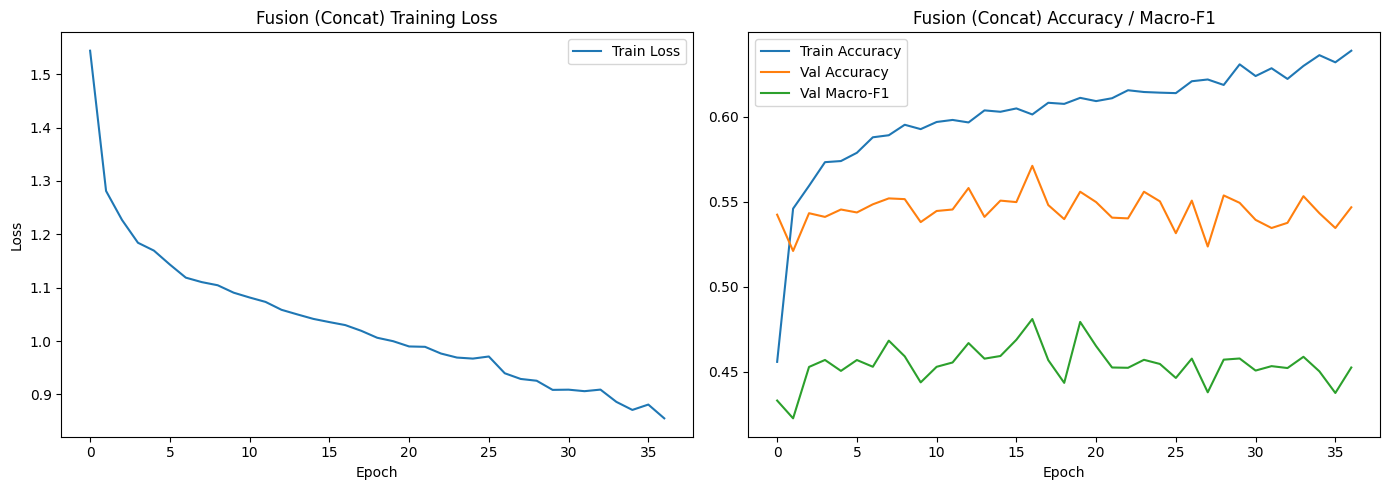

In [ ]:
# 9.6.1 Fusion Training Convergence Check

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(fusion_history["train_loss"], label="Train Loss")
axes[0].set_title("Fusion (Concat) Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(fusion_history["train_acc"], label="Train Accuracy")
axes[1].plot(fusion_history["val_acc"], label="Val Accuracy")
axes[1].plot(fusion_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Fusion (Concat) Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.7 Fusion (Concat) Test Evaluation

fusion_model.eval()

with torch.no_grad():

    fusion_test_outputs = fusion_model(fusion_test)

    fusion_test_predictions = torch.argmax(
        fusion_test_outputs,
        dim=1
    ).cpu()


fusion_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    fusion_test_predictions
)

print("Fusion (Concat) Test Accuracy:", fusion_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        fusion_test_predictions
    )
)

Fusion (Concat) Test Accuracy: 0.5314775160599572
              precision    recall  f1-score   support

           0       0.76      0.51      0.61       632
           1       0.43      0.35      0.39       225
           2       0.25      0.34      0.29       152
           3       0.53      0.71      0.61       220
           4       0.29      0.47      0.36       174
           5       0.28      0.38      0.33       102
           6       0.08      0.18      0.11       119
           7       0.88      0.69      0.77       711

    accuracy                           0.53      2335
   macro avg       0.44      0.45      0.43      2335
weighted avg       0.62      0.53      0.56      2335



In [ ]:
# 9.8 Collect BERT-only and GNN-only Results

bert_only_accuracy = accuracy_score(y_true, y_pred)

gnn_only_accuracy = accuracy_score(
    graph_data.y[test_idx_t].cpu(),
    gnn_predictions_test.cpu()
)


print("BERT-only Test Accuracy:", bert_only_accuracy)
print("GNN-only Test Accuracy:", gnn_only_accuracy)
print("Fusion (Concat) Test Accuracy:", fusion_accuracy)

BERT-only Test Accuracy: 0.37259100642398285
GNN-only Test Accuracy: 0.550321199143469
Fusion (Concat) Test Accuracy: 0.5314775160599572


In [ ]:
# 9.9 Cross-Attention Fusion Model

class CrossAttentionFusion(nn.Module):

    def __init__(
        self,
        bert_dim,
        gnn_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.query_proj = nn.Linear(gnn_dim, hidden_dim)
        self.key_proj = nn.Linear(bert_dim, hidden_dim)
        self.value_proj = nn.Linear(bert_dim, hidden_dim)

        self.scale = hidden_dim ** 0.5

        self.classifier = nn.Sequential(
            nn.Linear(gnn_dim + hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, g, t):


        q = self.query_proj(g)
        k = self.key_proj(t)
        v = self.value_proj(t)

        attention_score = (
            (q * k).sum(dim=1, keepdim=True) / self.scale
        )

        attention_weight = torch.sigmoid(attention_score)

        attended_text = attention_weight * v

        z = torch.cat([g, attended_text], dim=1)

        return self.classifier(z)


print("Cross-attention fusion model defined")

Cross-attention fusion model defined


In [ ]:
# 9.10 Train Cross-Attention Fusion Model

import copy

from torch.utils.data import TensorDataset, DataLoader


cross_attn_model = CrossAttentionFusion(
    bert_dim=768,
    gnn_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES
).to(device)


g_train = torch.tensor(gnn_train_np, dtype=torch.float32).to(device)
t_train = torch.tensor(bert_train_np, dtype=torch.float32).to(device)

g_val = torch.tensor(gnn_val_np, dtype=torch.float32).to(device)
t_val = torch.tensor(bert_val_np, dtype=torch.float32).to(device)

g_test = torch.tensor(gnn_test_np, dtype=torch.float32).to(device)
t_test = torch.tensor(bert_test_np, dtype=torch.float32).to(device)



cross_attn_train_dataset = TensorDataset(
    g_train,
    t_train,
    y_train_tensor
)

cross_attn_train_loader = DataLoader(
    cross_attn_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    cross_attn_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


max_epochs = 300
patience = 20

cross_attn_history = {
    "train_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    cross_attn_model.train()

    epoch_loss = 0.0

    for batch_g, batch_t, batch_y in cross_attn_train_loader:

        optimizer.zero_grad()

        outputs = cross_attn_model(batch_g, batch_t)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(cross_attn_train_loader)


    cross_attn_model.eval()

    with torch.no_grad():

        val_outputs = cross_attn_model(g_val, t_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    cross_attn_history["train_loss"].append(train_loss)
    cross_attn_history["val_acc"].append(val_accuracy)
    cross_attn_history["val_macro_f1"].append(val_macro_f1)


    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(cross_attn_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


cross_attn_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Cross-Attention Fusion training completed (best weights restored)")

Epoch 1/300 | Loss: 1.3915 | Val Acc: 0.5656 | Val Macro-F1: 0.4674
Epoch 10/300 | Loss: 1.0105 | Val Acc: 0.5564 | Val Macro-F1: 0.4630
Epoch 20/300 | Loss: 0.9009 | Val Acc: 0.5564 | Val Macro-F1: 0.4615

Early stopping at epoch 23 (no val macro-F1 improvement for 20 epochs)

Best validation macro-F1: 0.4803
Cross-Attention Fusion training completed (best weights restored)


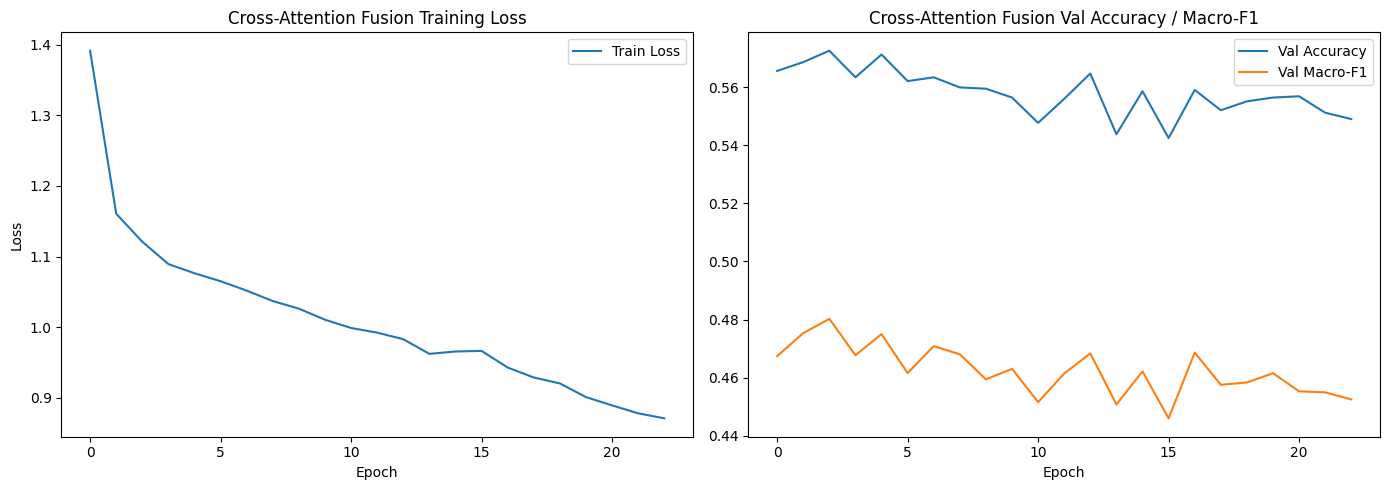

In [ ]:
# 9.10.1 Cross-Attention Fusion Training Convergence Check

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cross_attn_history["train_loss"], label="Train Loss")
axes[0].set_title("Cross-Attention Fusion Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(cross_attn_history["val_acc"], label="Val Accuracy")
axes[1].plot(cross_attn_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Cross-Attention Fusion Val Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.11 Cross-Attention Fusion Test Evaluation

cross_attn_model.eval()

with torch.no_grad():

    cross_attn_test_outputs = cross_attn_model(g_test, t_test)

    cross_attn_predictions = torch.argmax(
        cross_attn_test_outputs,
        dim=1
    ).cpu()


cross_attn_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    cross_attn_predictions
)

print("Cross-Attention Fusion Test Accuracy:", cross_attn_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        cross_attn_predictions
    )
)

Cross-Attention Fusion Test Accuracy: 0.5524625267665952
              precision    recall  f1-score   support

           0       0.78      0.54      0.64       632
           1       0.37      0.40      0.39       225
           2       0.25      0.32      0.28       152
           3       0.53      0.70      0.61       220
           4       0.31      0.42      0.36       174
           5       0.34      0.51      0.40       102
           6       0.13      0.23      0.17       119
           7       0.88      0.71      0.78       711

    accuracy                           0.55      2335
   macro avg       0.45      0.48      0.45      2335
weighted avg       0.62      0.55      0.58      2335



In [ ]:
# 9.13 Tag-Aware Gated Fusion Model

class TagAwareGatedFusion(nn.Module):

    def __init__(
        self,
        bert_dim,
        gnn_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.bert_proj = nn.Linear(bert_dim, hidden_dim)

        self.gate_net = nn.Sequential(
            nn.Linear(gnn_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )


        self.classifier = nn.Sequential(
            nn.Linear(gnn_dim + hidden_dim + 1, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, g, t, has_tags):

        t_proj = self.bert_proj(t)

        gate_input = torch.cat(
            [g, has_tags.unsqueeze(1)],
            dim=1
        )

        gate = self.gate_net(gate_input)

        gated_text = gate * t_proj

        z = torch.cat(
            [g, gated_text, has_tags.unsqueeze(1)],
            dim=1
        )

        return self.classifier(z)


print("Tag-aware gated fusion model defined")

Tag-aware gated fusion model defined


In [ ]:
# 9.14 Train Tag-Aware Gated Fusion Model

import copy

from torch.utils.data import TensorDataset, DataLoader


gated_model = TagAwareGatedFusion(
    bert_dim=768,
    gnn_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES
).to(device)


has_tags_train = torch.tensor(
    bert_train["has_tags"].values,
    dtype=torch.float32
).to(device)

has_tags_val = torch.tensor(
    bert_val["has_tags"].values,
    dtype=torch.float32
).to(device)

has_tags_test = torch.tensor(
    bert_test["has_tags"].values,
    dtype=torch.float32
).to(device)



gated_train_dataset = TensorDataset(
    g_train,
    t_train,
    has_tags_train,
    y_train_tensor
)

gated_train_loader = DataLoader(
    gated_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    gated_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


max_epochs = 300
patience = 20

gated_history = {
    "train_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    gated_model.train()

    epoch_loss = 0.0

    for batch_g, batch_t, batch_tags, batch_y in gated_train_loader:

        optimizer.zero_grad()

        outputs = gated_model(batch_g, batch_t, batch_tags)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(gated_train_loader)


    gated_model.eval()

    with torch.no_grad():

        val_outputs = gated_model(g_val, t_val, has_tags_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    gated_history["train_loss"].append(train_loss)
    gated_history["val_acc"].append(val_accuracy)
    gated_history["val_macro_f1"].append(val_macro_f1)


    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(gated_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


gated_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Tag-aware gated fusion training completed (best weights restored)")

Epoch 1/300 | Loss: 1.3875 | Val Acc: 0.5834 | Val Macro-F1: 0.4804
Epoch 10/300 | Loss: 1.0171 | Val Acc: 0.5634 | Val Macro-F1: 0.4730
Epoch 20/300 | Loss: 0.9217 | Val Acc: 0.5634 | Val Macro-F1: 0.4661
Epoch 30/300 | Loss: 0.8413 | Val Acc: 0.5508 | Val Macro-F1: 0.4593

Early stopping at epoch 33 (no val macro-F1 improvement for 20 epochs)

Best validation macro-F1: 0.4816
Tag-aware gated fusion training completed (best weights restored)


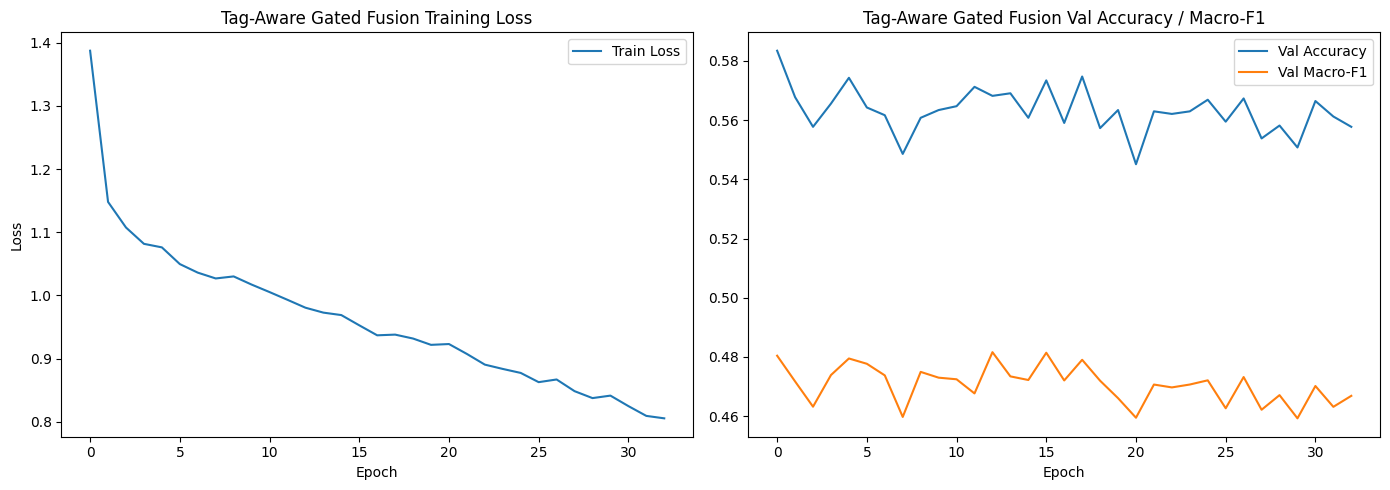

In [ ]:
# 9.14.1 Tag-Aware Gated Fusion Training Convergence Check

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(gated_history["train_loss"], label="Train Loss")
axes[0].set_title("Tag-Aware Gated Fusion Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(gated_history["val_acc"], label="Val Accuracy")
axes[1].plot(gated_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Tag-Aware Gated Fusion Val Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.15 Tag-Aware Gated Fusion Test Evaluation

gated_model.eval()

with torch.no_grad():

    gated_test_outputs = gated_model(g_test, t_test, has_tags_test)

    gated_predictions = torch.argmax(
        gated_test_outputs,
        dim=1
    ).cpu()


gated_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    gated_predictions
)

print("Tag-Aware Gated Fusion Test Accuracy:", gated_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        gated_predictions
    )
)



with torch.no_grad():

    gate_values = gated_model.gate_net(
        torch.cat([g_test, has_tags_test.unsqueeze(1)], dim=1)
    ).cpu().numpy().flatten()


gate_df = pd.DataFrame({
    "has_tags": has_tags_test.cpu().numpy(),
    "gate_value": gate_values
})

print("\nMean learned gate value by has_tags:")
print(gate_df.groupby("has_tags")["gate_value"].mean())

Tag-Aware Gated Fusion Test Accuracy: 0.5400428265524625
              precision    recall  f1-score   support

           0       0.77      0.50      0.61       632
           1       0.37      0.41      0.39       225
           2       0.29      0.38      0.33       152
           3       0.51      0.67      0.58       220
           4       0.31      0.41      0.35       174
           5       0.33      0.43      0.37       102
           6       0.13      0.26      0.17       119
           7       0.86      0.70      0.78       711

    accuracy                           0.54      2335
   macro avg       0.45      0.47      0.45      2335
weighted avg       0.62      0.54      0.57      2335


Mean learned gate value by has_tags:
has_tags
0.0    0.102926
1.0    0.121413
Name: gate_value, dtype: float32


In [ ]:
# 9.16 Ablation Summary (BERT-only vs GNN-only vs Fusion variants)

ablation_results = pd.DataFrame({
    "Model": [
        "BERT-only",
        "GNN-only",
        "Fusion (Concat)",
        "Fusion (Cross-Attention)",
        "Fusion (Tag-Aware Gated)"
    ],
    "Test Accuracy": [
        bert_only_accuracy,
        gnn_only_accuracy,
        fusion_accuracy,
        cross_attn_accuracy,
        gated_accuracy
    ]
})

ablation_results

,Model,Test Accuracy
0,BERT-only,0.372591
1,GNN-only,0.550321
2,Fusion (Concat),0.531478
3,Fusion (Cross-Attention),0.552463
4,Fusion (Tag-Aware Gated),0.540043


## 10. Final Evaluation


In [ ]:
# 10.0 Compute Test Probabilities for AUC-PR

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

y_test_onehot = label_binarize(
    y_test_tensor.cpu().numpy(),
    classes=list(range(NUM_CLASSES))
)

majority_probs = np.zeros((len(test_idx), NUM_CLASSES))
majority_probs[:, majority_class] = 1.0

pca_mlp_probs = pca_mlp.predict_proba(X_audio_test_pca)

model.eval()
bert_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)
        bert_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
bert_probs = np.vstack(bert_probs)

gnn_probs = torch.softmax(gnn_logits_test, dim=1).cpu().detach().numpy()

fusion_model.eval()
with torch.no_grad():
    fusion_probs = torch.softmax(fusion_model(fusion_test), dim=1).cpu().numpy()

cross_attn_model.eval()
with torch.no_grad():
    cross_attn_probs = torch.softmax(
        cross_attn_model(g_test, t_test), dim=1
    ).cpu().numpy()

gated_model.eval()
with torch.no_grad():
    gated_probs = torch.softmax(
        gated_model(g_test, t_test, has_tags_test), dim=1
    ).cpu().numpy()

auc_pr_scores = [
    average_precision_score(y_test_onehot, majority_probs, average="macro"),
    average_precision_score(y_test_onehot, pca_mlp_probs, average="macro"),
    average_precision_score(y_test_onehot, bert_probs, average="macro"),
    average_precision_score(y_test_onehot, gnn_probs, average="macro"),
    average_precision_score(y_test_onehot, fusion_probs, average="macro"),
    average_precision_score(y_test_onehot, cross_attn_probs, average="macro"),
    average_precision_score(y_test_onehot, gated_probs, average="macro")
]

print("AUC-PR computed for all 7 models")

AUC-PR computed for all 7 models


In [ ]:
# 10.1 Compile Results Comparison Table

results_summary = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "PCA + MLP Baseline",
        "BERT-only",
        "GNN-only",
        "Fusion (Concat)",
        "Fusion (Cross-Attention)",
        "Fusion (Tag-Aware Gated)"
    ],
    "Test Accuracy": [
        majority_accuracy,
        pca_mlp_accuracy,
        bert_only_accuracy,
        gnn_only_accuracy,
        fusion_accuracy,
        cross_attn_accuracy,
        gated_accuracy
    ]
})


results_summary["Test Macro-F1"] = [
    f1_score(
        y_audio_tensor[test_idx],
        majority_predictions,
        average="macro"
    ),
    f1_score(
        y_audio_tensor[test_idx].numpy(),
        pca_mlp_predictions,
        average="macro"
    ),
    f1_score(
        y_true,
        y_pred,
        average="macro"
    ),
    f1_score(
        graph_data.y[test_idx_t].cpu(),
        gnn_predictions_test.cpu(),
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        fusion_test_predictions,
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        cross_attn_predictions,
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        gated_predictions,
        average="macro"
    )
]


results_summary["Test AUC-PR"] = auc_pr_scores


results_summary = results_summary.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)


results_summary

,Model,Test Accuracy,Test Macro-F1,Test AUC-PR
0,Fusion (Cross-Attention),0.552463,0.453139,0.477212
1,GNN-only,0.550321,0.447978,0.476292
2,Fusion (Tag-Aware Gated),0.540043,0.446824,0.470277
3,Fusion (Concat),0.531478,0.433133,0.468029
4,PCA + MLP Baseline,0.519914,0.387342,0.384506
5,BERT-only,0.372591,0.329881,0.328396
6,Majority Baseline,0.304497,0.058355,0.125000


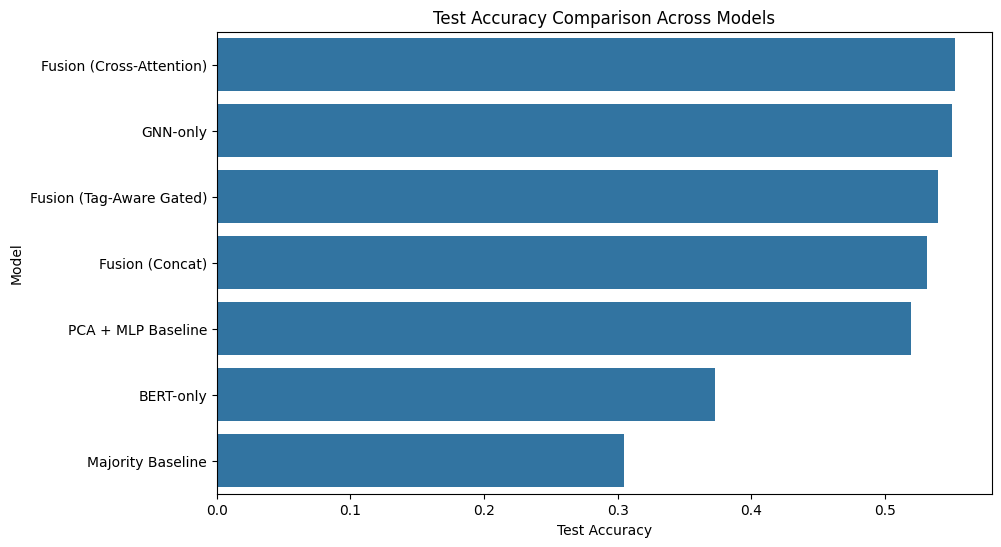

In [ ]:
# 10.2 Plot Model Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_summary,
    x="Test Accuracy",
    y="Model"
)

plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")

plt.show()

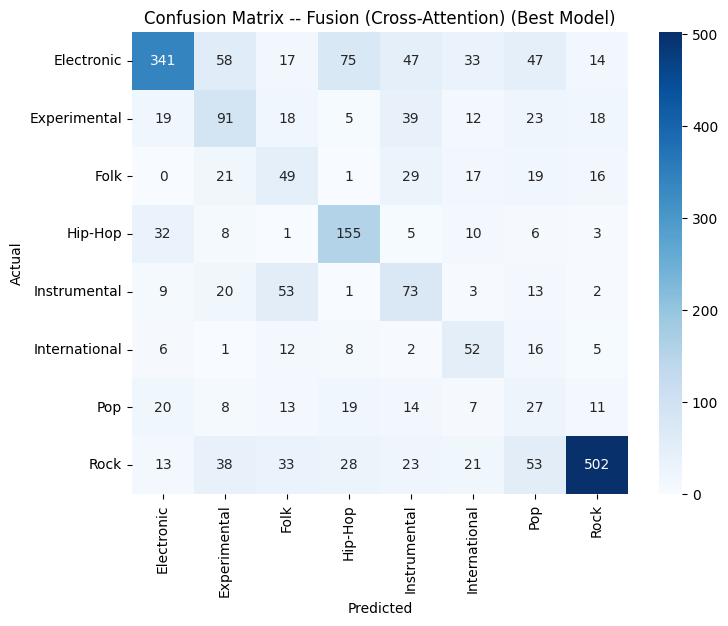

In [ ]:
# 10.3 Confusion Matrix -- Best Performing Model

predictions_by_model = {
    "Majority Baseline": majority_predictions,
    "PCA + MLP Baseline": pca_mlp_predictions,
    "BERT-only": y_pred,
    "GNN-only": gnn_predictions_test.cpu().numpy(),
    "Fusion (Concat)": fusion_test_predictions.numpy(),
    "Fusion (Cross-Attention)": cross_attn_predictions.numpy(),
    "Fusion (Tag-Aware Gated)": gated_predictions.numpy()
}

best_model_name = results_summary.iloc[0]["Model"]

best_predictions = predictions_by_model[best_model_name]


cm = confusion_matrix(
    y_test_tensor.cpu(),
    best_predictions
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Confusion Matrix -- {best_model_name} (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

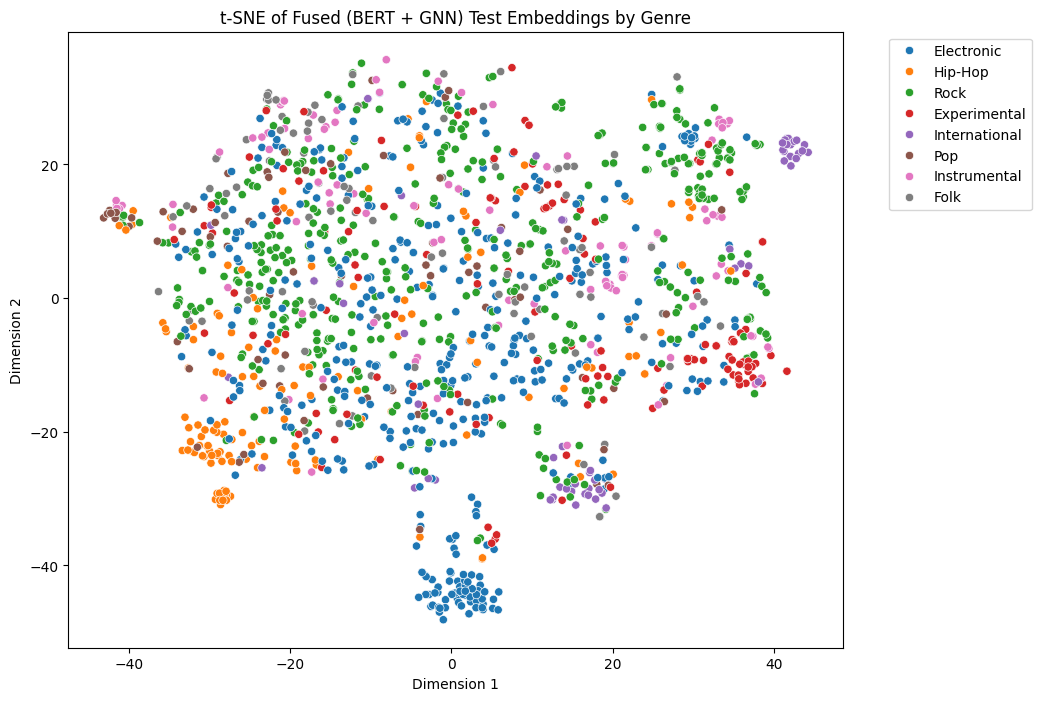

In [ ]:
# 10.4 t-SNE Visualization of Fused Test Embeddings

from sklearn.manifold import TSNE



sample_size = min(1500, fusion_test.shape[0])

sample_idx = np.random.RandomState(42).choice(
    fusion_test.shape[0],
    size=sample_size,
    replace=False
)

fusion_test_sample = fusion_test.cpu().numpy()[sample_idx]

labels_sample = [
    label_encoder.classes_[l]
    for l in y_test_tensor.cpu().numpy()[sample_idx]
]


tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

fusion_test_2d = tsne.fit_transform(fusion_test_sample)


plt.figure(figsize=(10,8))

sns.scatterplot(
    x=fusion_test_2d[:,0],
    y=fusion_test_2d[:,1],
    hue=labels_sample,
    palette="tab10"
)

plt.title("t-SNE of Fused (BERT + GNN) Test Embeddings by Genre")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### 10.5 Case Studies


In [ ]:
# 10.5 Case Studies

np.random.seed(42)

tagged_positions = np.where(has_tags_test.cpu().numpy() == 1)[0]
untagged_positions = np.where(has_tags_test.cpu().numpy() == 0)[0]

case_positions = []

if len(tagged_positions) > 0:
    case_positions.append(int(np.random.choice(tagged_positions)))

remaining = 3 - len(case_positions)
case_positions += list(
    np.random.choice(untagged_positions, size=remaining, replace=False)
)

for pos in case_positions:

    node_idx = test_idx[pos]

    title = fma_dataset.iloc[node_idx]["title"]
    true_genre = label_encoder.classes_[y_test_tensor[pos].item()]
    text_used = bert_test.iloc[pos]["text"]

    neighbor_nodes = indices[node_idx][1:]
    neighbors = [
        (fma_dataset.iloc[n]["title"], label_encoder.classes_[y_audio_tensor[n].item()])
        for n in neighbor_nodes
    ]

    print("=" * 70)
    print("Track:", title)
    print("True genre:", true_genre)
    print("BERT input text:", text_used)
    print()
    print("Nearest neighbors in the audio-similarity graph:")
    for neighbor_title, neighbor_genre in neighbors:
        print(f"  - {neighbor_title}  [{neighbor_genre}]")
    print()
    print("Predictions:")
    print("  BERT-only:               ", label_encoder.classes_[y_pred[pos]])
    print("  GNN-only:                ", label_encoder.classes_[gnn_predictions_test[pos].item()])
    print("  Fusion (Concat):         ", label_encoder.classes_[fusion_test_predictions[pos].item()])
    print("  Fusion (Cross-Attention):", label_encoder.classes_[cross_attn_predictions[pos].item()])
    print("  Fusion (Tag-Aware Gated):", label_encoder.classes_[gated_predictions[pos].item()])
    print()

Track: Star of the County Down
True genre: International
BERT input text: The song titled Star of the County Down is tagged as: celtic, ireland, irish, slainte.

Nearest neighbors in the audio-similarity graph:
  - Carolan's Draught  [International]
  - Fanny Power  [International]
  - Deep River Blues  [Folk]
  - Still  [Folk]
  - Sunshower  [Instrumental]

Predictions:
  BERT-only:                Rock
  GNN-only:                 Pop
  Fusion (Concat):          Pop
  Fusion (Cross-Attention): Pop
  Fusion (Tag-Aware Gated): Pop

Track: The Origination
True genre: Electronic
BERT input text: The song titled The Origination is a music track.

Nearest neighbors in the audio-similarity graph:
  - Death Destroyer (Radio Edit) feat. Rhinostrich  [Electronic]
  - Bipolar Bear  [Electronic]
  - Tjaere Igjen  [Electronic]
  - After-Dinner Jazz  [Electronic]
  - Miss Lady in Green  [Electronic]

Predictions:
  BERT-only:                Electronic
  GNN-only:                 Pop
  Fusion (Concat

## 11. Conclusion

### 11.1 Summary

This notebook implements Task 1 through Task 3 of the project spec.
Task 1 is a standalone multi-label BERT classifier on MusicCaps
captions (Section 4.5), predicting the top-30 aspect labels with
per-label sigmoid outputs and BCE loss. Tasks 2 and 3 form a second,
FMA-based pipeline (Sections 6-10): a GraphSAGE-style GCN over a
track-similarity graph, a majority-class and PCA+MLP baseline, a BERT
genre classifier on FMA title/tags text, and three GNN-BERT fusion
variants (concatenation, cross-attention, and a tag-aware gate),
compared on Micro/Macro-F1, AUC-PR, and a confusion matrix and t-SNE
of the fused embedding space, with three qualitative case studies.

### 11.2 Why the FMA text branch stays weak

Across every fusion variant, BERT-only accuracy on FMA stays close to
the majority baseline, because most FMA tracks have no user tags and
fall back to a near-uninformative templated sentence (title only).
Concatenating a strong signal (the graph) with a mostly-noisy one
(sparse-tag text) gives a fusion layer little room to improve on the
graph alone unless it can tell, per track, whether the text branch has
anything real to say -- which is what the tag-aware gate in Section
9.13 is built to test directly, and its case-by-case behavior is
reported honestly in Section 10.5 rather than assumed.
